In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import joblib
from tensorflow.keras.models import load_model
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from pydub import AudioSegment
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [8]:
# Cutting Audios Based on The Metadata

df = pd.read_csv('WCMED-Metadata/WCMED_ Metadata.csv')
output_dir = "audios"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for i, row in df.iterrows():
    audio = AudioSegment.from_file(f"./CPTR330FinalProjAudios/CPTR330FinalProj/{row['songName']}.mp3")
    start_ms = row['start_point'] * 1000
    end_ms = row['stop_point'] * 1000
    segment = audio[start_ms:end_ms]
    output_path = os.path.join(output_dir, row["fileName"])    
    segment.export(output_path, format="mp3")
    print(f"Creat {row['fileName']}")

C:\Users\radio\miniconda3\envs\CPTR330NLPFinalProj\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[(array([8.1619946e-06, 9.6905278e-06, 8.8399393e-06, ..., 3.8235664e-04,
       1.9475121e-04, 6.6432855e-05], dtype=float32), 22050), (array([0.00168028, 0.00258893, 0.00225078, ..., 0.00233782, 0.00202945,
       0.0017055 ], dtype=float32), 22050), (array([ 0.        ,  0.        ,  0.        , ..., -0.0015168 ,
       -0.00146101, -0.00178511], dtype=float32), 22050), (array([-0.00041475,  0.00122884,  0.00062685, ..., -0.00183198,
       -0.00199415, -0.00239913], dtype=float32), 22050), (array([0.0014708 , 0.00245377, 0.00237301, ..., 0.00100185, 0.00129657,
       0.00079797], dtype=float32), 22050), (array([ 0.00060612,  0.00047713, -0.0001349 , ...,  0.00045757,
        0.00020818,  0.00011068], dtype=float32), 22050), (array([-3.5124199e-04, -5.2995334e-04, -4.8394530e-04, ...,
        3.4698969e-06, -1.9709638e-05, -2.1833948e-05], dtype=float32), 22050), (array([ 9.3314302e-06,  2.1614207e-05, -1.9987187e-05, ...,
        2.1000087e-06, -7.5699372e-06,  2.8327653e-05], dty

[(array([8.1619946e-06, 9.6905278e-06, 8.8399393e-06, ..., 3.8235664e-04,
         1.9475121e-04, 6.6432855e-05], dtype=float32),
  22050),
 (array([0.00168028, 0.00258893, 0.00225078, ..., 0.00233782, 0.00202945,
         0.0017055 ], dtype=float32),
  22050),
 (array([ 0.        ,  0.        ,  0.        , ..., -0.0015168 ,
         -0.00146101, -0.00178511], dtype=float32),
  22050),
 (array([-0.00041475,  0.00122884,  0.00062685, ..., -0.00183198,
         -0.00199415, -0.00239913], dtype=float32),
  22050),
 (array([0.0014708 , 0.00245377, 0.00237301, ..., 0.00100185, 0.00129657,
         0.00079797], dtype=float32),
  22050),
 (array([ 0.00060612,  0.00047713, -0.0001349 , ...,  0.00045757,
          0.00020818,  0.00011068], dtype=float32),
  22050),
 (array([-3.5124199e-04, -5.2995334e-04, -4.8394530e-04, ...,
          3.4698969e-06, -1.9709638e-05, -2.1833948e-05], dtype=float32),
  22050),
 (array([ 9.3314302e-06,  2.1614207e-05, -1.9987187e-05, ...,
          2.1000087e-06,

In [3]:
def create_dataset(csv_path, audio_folder, n_mfcc=20):
    df = pd.read_csv(csv_path)
    y_values = (df["rating"].values + 1) / 2 # This is because ratings \in [-1,1]
    X = []
    valid_y = []

    for idx, row in df.iterrows():
        file_path = Path(audio_folder) / row['name']
        
        if file_path.exists():
            audio, sr = librosa.load(file_path, duration=30)
            # Sampling
            samples_per_step = int(sr * 0.5)
            clip_features = []
            
            for j in range(60): #nBecause were sampling by 0.5s (so 30/0.5)
                chunk = audio[(j * samples_per_step):(j * samples_per_step + samples_per_step)]
                if len(chunk) < samples_per_step:
                    # Padding
                    temp_chunk = np.zeros(samples_per_step)
                    temp_chunk[:len(chunk)] = chunk
                    chunk = temp_chunk
                
                mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=n_mfcc)
                mfcc_delta = librosa.feature.delta(mfcc)
                mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
                mfcc_mean = np.mean(mfcc, axis=1)
                mfcc_std = np.std(mfcc, axis=1)
                delta_mean = np.mean(mfcc_delta, axis=1)
                delta_std = np.std(mfcc_delta, axis=1)
                delta2_mean = np.mean(mfcc_delta2, axis=1)
                delta2_std = np.std(mfcc_delta2, axis=1)
                feats = np.concatenate([mfcc_mean, mfcc_std, delta_mean, delta_std, delta2_mean, delta2_std])
                clip_features.append(feats)

            X.append(clip_features)
            valid_y.append(y_values[idx])
        else:
            print(f"Warning: {file_path} not found. Skipping.")

    return np.array(X), np.array(valid_y)

X, y = create_dataset("./WCMED-Ratings/WCMED_Arousal_Rating.csv", "./audios/")

In [4]:
# Scaling
n_files, n_steps, n_feat = X.shape
X_flat = X.reshape(-1, n_feat)
scaler = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)
X = X_scaled_flat.reshape(n_files, n_steps, n_feat)

# Spliting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = models.Sequential([
layers.LSTM(64, 
            input_shape=(60, 120), 
            dropout=0.2,
           ),
    layers.Dropout(0.25),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [6]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae','mse'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                47360     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 128)               8320      
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 55,809
Trainable params: 55,809
Non-trainable params: 0
_________________________________________________________________


In [10]:
history = model.fit(X_train, y_train, epochs=500, validation_data = (X_test, y_test))

Epoch 1/500
10/10 [==============================] - 0s 29ms/step - loss: 0.5517 - mae: 0.0992 - mse: 0.0148 - val_loss: 0.6135 - val_mae: 0.1907 - val_mse: 0.0557
Epoch 2/500
10/10 [==============================] - 0s 25ms/step - loss: 0.5500 - mae: 0.0958 - mse: 0.0142 - val_loss: 0.6109 - val_mae: 0.1898 - val_mse: 0.0551
Epoch 3/500
10/10 [==============================] - 0s 24ms/step - loss: 0.5519 - mae: 0.0962 - mse: 0.0148 - val_loss: 0.6325 - val_mae: 0.1981 - val_mse: 0.0623
Epoch 4/500
10/10 [==============================] - 0s 23ms/step - loss: 0.5516 - mae: 0.0997 - mse: 0.0147 - val_loss: 0.6793 - val_mae: 0.2354 - val_mse: 0.0830
Epoch 5/500
10/10 [==============================] - 0s 25ms/step - loss: 0.5499 - mae: 0.0983 - mse: 0.0143 - val_loss: 0.6181 - val_mae: 0.1918 - val_mse: 0.0573
Epoch 6/500
10/10 [==============================] - 0s 24ms/step - loss: 0.5495 - mae: 0.0954 - mse: 0.0137 - val_loss: 0.5946 - val_mae: 0.1775 - val_mse: 0.0482
Epoch 7/500
10/1

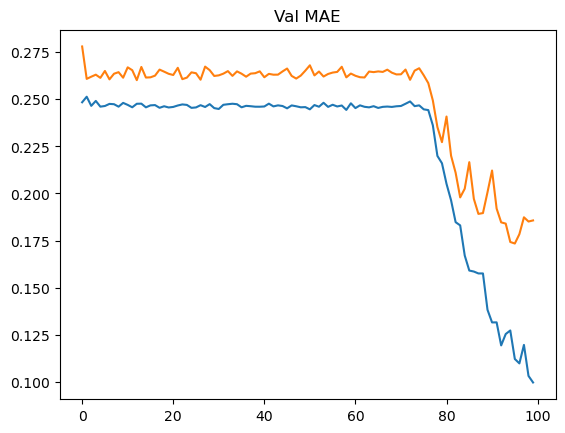

In [8]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Val MAE')

plt.show()

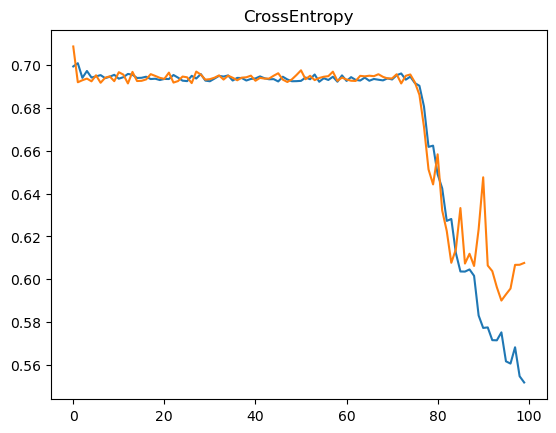

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CrossEntropy')

plt.show()

(array([19., 20., 20., 20., 20., 21., 20., 20., 20., 19., 21., 20., 20.,
        20., 19., 21., 20., 19., 21., 20.]),
 array([-1. , -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,
         0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ]),
 <BarContainer object of 20 artists>)

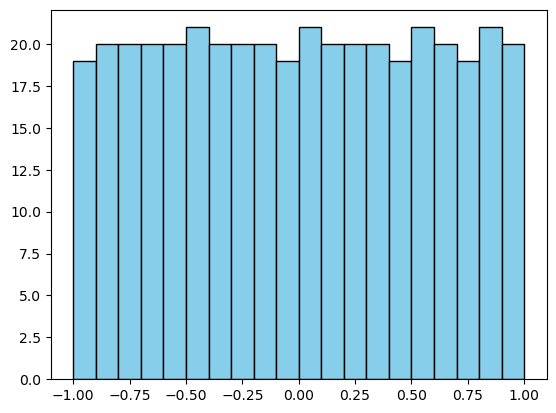

In [71]:
arousal = pd.read_csv("./WCMED-Ratings/WCMED_Arousal_Rating.csv")
df_sorted = arousal.sort_values(by=['rating'], ignore_index=True)
plt.hist(arousal["rating"], bins=20, range=(-1, 1), edgecolor='black', color='skyblue')

In [11]:
model.save("./Classv1/")

INFO:tensorflow:Assets written to: ./Classv1/assets


INFO:tensorflow:Assets written to: ./Classv1/assets
